# Deep Learning Konseptleri

Bu notebook, derin öğrenme temel kavramlarını, NLP, Computer Vision ve Speech teknolojilerini kapsayan kapsamlı bir eğitim materyalidir.

## Gerekli Kütüphanelerin Kurulumu

Aşağıdaki hücreyi çalıştırarak gerekli kütüphaneleri kurun:

In [43]:
# Gerekli kütüphanelerin kurulumu
!pip install torch torchvision torchaudio transformers gensim librosa matplotlib opencv-python webrtcvad phonemizer g2p-en openai-whisper coqui-tts

In [2]:
# Temel importlar
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

---
# 1. Deep Learning Temelleri

Makine öğrenmesinde veriden anlam çıkarmaya çalışıyorduk. Verisetine sorular soruyor bir verinin özelliklerini biz çıkarmaya çalışıyorduk.

Derin öğrenme de model veri setindeki özellikleri, patternleri kendi öğrenir. Kendi öğrenmekten kasıt nedir burada? Neye dayanarak öğreniyor? Bir doğruya bakarak kendini güncellenmesi gerekir modelin.

### Temel Kavramlar
- Perceptron
- Derinlik
- Input
- Nöron
- Hidden Layers
- Aktivasyon Fonksiyonları
- Forward Pass
- Loss Fonksiyonları
- Backpropagation
- Optimizer
- Parametreler ve Hiperparametreler
- Model Değerlendirmesi

### Basit Tek Katmanlı Model - Perceptron

İlk önce **perceptron** vardı 1957'de. Tek katmanlı yapay sinir ağı. Girdileri alır, ağırlıkla çarpar, bias ile toplar ve bir eşikten geçirir yani aktivasyon fonksiyonu uygular. Sonucunda bir karar verir. Bu klasik bir lineer binary sınıflandırıcıdır aslında.

Hatta perceptron'un aktivasyon fonksiyonu sigmoid, loss fonksiyonu binary cross entropy ise bu aslında ikili sınıflandırma yapan makine öğrenmesi modeli Logistic Regresyon'dur.

### Derinlik, Katmanlar

Tek katmanlı Perceptron yalnızca lineer durumlarda çalışabilir.

Derin öğrenmede non-lineer durumları çözülebilir yapan, ev-fiyat tahminini geçip yüz tanımayı mümkün kılan derinliktir. Derin öğrenme modelin derinliği katmanlarıdır.

**Birden fazla katman (hidden layers)** eklendiği anda, model artık:
- lineer olmayan temsiller öğrenebilir
- karmaşık fonksiyonları yaklaşıklar

Fakat derinlik her zaman iyi değildir. Gereğinden fazla derinlik karmaşıklık yaratıp modeli overfitting'e sürükleyebilirken probleme göre fazla basit bir modelde verileri iyi öğrenemeyebilir.

### Nöron: Öğrenmenin En Küçük Birimi

Bir nöronun yaptığı şey:
- Her girdiyi bir **ağırlık (weight)** ile çarpar
- Hepsini toplar
- Üzerine bir **bias** ekler
- Sonucu bir **aktivasyon fonksiyonundan** geçirir

Matematiksel olarak:

$$y = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b$$

Burada:
- **x**: girdiler
- **w**: ağırlıklar (öğrenilen kısım)
- **b (bias)**: modelin esnekliğini artıran sabit
- **y**: aktivasyondan önceki çıktı

### Aktivasyon Fonksiyonları: Lineerliği Kıran Şey

Eğer katmanlar arasında aktivasyon fonksiyonu olmazsa, ne kadar çok katman koyarsak koyalım model hâlâ **lineer** kalır.

En sık karşılaşılanlar:
- **Sigmoid**: Çıktıyı 0–1 arasına sıkıştırır → Olasılık yorumları için uygun
- **Tanh**: –1 ile 1 arası
- **ReLU (Rectified Linear Unit)**: f(x) = max(0, x) → Derin ağlarda devrim etkisi yaratmıştır
- **Softmax**: Çok sınıflı problemlerde, çıktıyı olasılık dağılımına çevirir

### Forward Pass, Loss Fonksiyonu, Backpropagation

**Forward Pass**: Veri input'tan girip katman katman ilerlerken yapılan işlem.

**Loss Function**: Modelin tahmini ile gerçek değer arasındaki farkı ölçen fonksiyon.
- Mean Squared Error (MSE) → regresyon
- Binary Cross Entropy → ikili sınıflandırma
- Categorical Cross Entropy → çok sınıflı problemler

**Backpropagation**: Hatanın ağ boyunca geriye doğru yayılması.
- Çıkıştaki hatayı hesapla
- Bu hatanın, her ağırlık üzerindeki etkisini bul
- Ağırlıkları hatayı azaltacak yönde güncelle

### Optimizer

Ağırlıkları güncellemek için bir stratejiye ihtiyacımız var.

En temel örnek: **Gradient Descent**

Daha gelişmiş olanlar:
- SGD
- Adam
- RMSProp

### Parametreler ve Hiperparametreler

**Parametreler**: Modelin öğrendiği şeyler (Ağırlıklar ve bias'lar)

**Hiperparametreler**: Modeli eğitirken bizim belirlediğimiz ayarlar
- Learning rate
- Katman sayısı
- Nöron sayısı
- Batch size
- Epoch sayısı

---
# 2. Natural Language Processing (NLP)

NLP'nin temel problemi:

> Bilgisayarlar sayıları anlar, insanlar dili konuşur.
> NLP, dili sayıya çevirme ve o sayıların anlamını öğrenme işidir.

### Tokenization (Parçalama)

Metni daha küçük parçalara ayırma işlemine **tokenization** denir.

Token:
- Bir kelime olabilir
- Bir alt kelime olabilir
- Hatta tek bir karakter olabilir

In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

sentence = "Makine öğrenmesi güzeldir"
tokens = tokenizer.tokenize(sentence)

print("Tokens:", tokens)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokens: ['ma', '##kin', '##e', 'og', '##ren', '##mes', '##i', 'gu', '##zel', '##di', '##r']


### Vocabulary (Sözlük)

Modelin bildiği tüm token'ların kümesine **vocabulary** denir.

- Vocabulary küçükse: ifade gücü sınırlı
- Çok büyükse: hesaplama maliyeti yüksek

In [4]:
vocab = tokenizer.get_vocab()

print("Vocabulary boyutu:", len(vocab))
print("İlk 10 token:", list(vocab.keys())[:10])

Vocabulary boyutu: 30522
İlk 10 token: ['sock', 'knots', 'pat', 'montenegrin', '[unused718]', '##kka', 'alistair', 'mattered', 'kitchens', '“']


### Embedding: Kelimelerin Anlam Kazanması

Token'ları numaralandırmak yetmez. "kedi = 42" demek, modele anlam vermez.

Embedding:
- Her kelimeyi sabit boyutlu bir vektöre çevirir
- Anlamsal benzerlikleri uzayda yakınlaştırır

Örnek sezgi:
- `kedi` → `[0.2, -1.3, 0.7, ...]`
- `köpek` → `[0.25, -1.1, 0.6, ...]`
- `araba` → çok daha uzak bir vektör

In [5]:
# Token'ları ID'lere çevirme
encoded = tokenizer(sentence)

print("Input IDs:", encoded["input_ids"])

Input IDs: [101, 5003, 4939, 2063, 13958, 7389, 7834, 2072, 19739, 12638, 4305, 2099, 102]


In [6]:
# PyTorch ile Embedding katmanı
import torch
import torch.nn as nn

embedding = nn.Embedding(num_embeddings=10000, embedding_dim=256)

token_ids = torch.tensor([5, 12, 432])
embedded_tokens = embedding(token_ids)

print("Embedded tokens shape:", embedded_tokens.shape)  # torch.Size([3, 256])

Embedded tokens shape: torch.Size([3, 256])


### Dağıtımsal Anlam (Distributional Semantics)

NLP'nin temel varsayımı:
> "Bir kelimenin anlamı, geçtiği bağlamlardan gelir."

Bu fikir Word2Vec, GloVe, FastText gibi embedding yöntemlerinin temelidir.

In [7]:
from gensim.models import Word2Vec

sentences = [
    ["kedi", "süt", "içti"],
    ["köpek", "su", "içti"],
    ["kedi", "mama", "yedi"]
]

model = Word2Vec(sentences, vector_size=50, window=2, min_count=1)

print("'kedi' kelimesine en benzer kelimeler:")
print(model.wv.most_similar("kedi"))

'kedi' kelimesine en benzer kelimeler:
[('su', 0.12486252933740616), ('süt', 0.07399575412273407), ('içti', 0.04237300902605057), ('köpek', 0.018277155235409737), ('yedi', 0.011071980930864811), ('mama', -0.17424818873405457)]


### Sequence (Sıra) Problemi

Dil sıraya duyarlıdır.

"köpek adamı ısırdı" & "adam köpeği ısırdı" → Aynı kelimeler, farklı anlam.

Bu yüzden NLP'de metin **sequence data** olarak ele alınır.

In [8]:
sentence1 = "köpek adamı ısırdı"
sentence2 = "adam köpeği ısırdı"

print("Cümle 1 IDs:", tokenizer(sentence1)["input_ids"])
print("Cümle 2 IDs:", tokenizer(sentence2)["input_ids"])

Cümle 1 IDs: [101, 12849, 5051, 2243, 4205, 11722, 1104, 2015, 11722, 4103, 11722, 102]
Cümle 2 IDs: [101, 4205, 12849, 5051, 5856, 1104, 2015, 11722, 4103, 11722, 102]


### RNN, LSTM, GRU: Hafızalı Modeller

**RNN (Recurrent Neural Network)**:
- Önceki kelimelerin bilgisini taşır
- Zaman boyunca açılan ağlar gibidir
- Problemi: uzun cümlelerde bilgi kaybı (vanishing gradient)

Çözüm:
- **LSTM (Long Short-Term Memory)**
- **GRU (Gated Recurrent Unit)**

Bu modeller ne unutulacak, ne hatırlanacak sorusuna kapılar (gates) ile karar verir.

In [9]:
# RNN örneği
rnn = nn.RNN(input_size=256, hidden_size=128, batch_first=True)

inputs = torch.randn(1, 5, 256)  # 5 kelimelik cümle
output, hidden = rnn(inputs)

print("RNN output shape:", output.shape)

RNN output shape: torch.Size([1, 5, 128])


In [10]:
# LSTM örneği - hafıza mekanizması ile uzun cümlelerde bilgi kaybını azaltır
lstm = nn.LSTM(input_size=256, hidden_size=128, batch_first=True)

output, (h, c) = lstm(inputs)
print("LSTM output shape:", output.shape)
print("Hidden state shape:", h.shape)
print("Cell state shape:", c.shape)

LSTM output shape: torch.Size([1, 5, 128])
Hidden state shape: torch.Size([1, 1, 128])
Cell state shape: torch.Size([1, 1, 128])


### Attention: Model Nereye Bakmalı?

Bir cümlede her kelime eşit derecede önemli değildir.

**Attention** mekanizması şunu sorar:
> "Şu anda tahmin yaparken, cümlenin hangi kısmına odaklanmalıyım?"

Matematiksel olarak:
- Ağırlıklı ortalamalar
- Benzerlik (dot product)
- Softmax

In [11]:
import torch.nn.functional as F

query = torch.randn(1, 256)
keys = torch.randn(5, 256)

scores = torch.matmul(keys, query.T)
weights = F.softmax(scores, dim=0)

print("Attention weights:")
print(weights)

Attention weights:
tensor([[2.1951e-12],
        [1.0000e+00],
        [1.5169e-09],
        [3.5270e-13],
        [9.4412e-09]])


### Transformer: NLP'nin Dönüm Noktası

Transformer mimarisi:
- RNN'leri tamamen bıraktı
- Attention'ı merkeze koydu

Temel bileşenler:
- Self-Attention
- Multi-Head Attention
- Feed Forward katmanlar
- Positional Encoding (sıra bilgisini kaybetmemek için)

Avantajları:
- Paralel hesaplama
- Uzun bağımlılıkları yakalama
- Ölçeklenebilirlik

BERT, GPT, T5 gibi modellerin tamamı Transformer tabanlıdır.

In [12]:
from transformers import AutoModel

model = AutoModel.from_pretrained("bert-base-uncased")

# Tokenize edilmiş girdiyi modele ver
encoded_input = tokenizer(sentence, return_tensors="pt")
outputs = model(**encoded_input)

print("Last hidden state shape:", outputs.last_hidden_state.shape)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Last hidden state shape: torch.Size([1, 13, 768])


### Positional Encoding: Sıra Bilgisi Nerede?

Transformer kelimeleri aynı anda görür. Ama sıra önemlidir.

Bu yüzden kelime embedding'lerine konum bilgisi eklenir. Sinüs-kosinüs fonksiyonları ya da öğrenilebilir vektörler kullanılır.

Positional Encoding shape: torch.Size([10, 16])


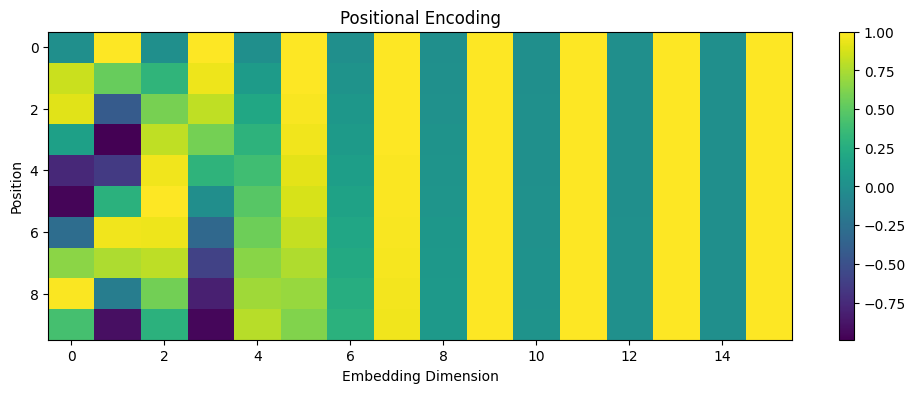

In [13]:
import math
import torch

def positional_encoding(seq_len, dim):
    pe = torch.zeros(seq_len, dim)
    for pos in range(seq_len):
        for i in range(0, dim, 2):
            pe[pos, i] = math.sin(pos / (10000 ** (i / dim)))
            pe[pos, i+1] = math.cos(pos / (10000 ** (i / dim)))
    return pe

pe = positional_encoding(10, 16)
print("Positional Encoding shape:", pe.shape)

# Görselleştirme
plt.figure(figsize=(12, 4))
plt.imshow(pe.numpy(), cmap='viridis', aspect='auto')
plt.xlabel('Embedding Dimension')
plt.ylabel('Position')
plt.title('Positional Encoding')
plt.colorbar()
plt.show()

### NLP Görevleri (Tasks)

- Text classification (duygu analizi)
- Named Entity Recognition (NER)
- Machine Translation
- Question Answering
- Summarization
- Language Modeling

Hepsi aynı temel yapıyı kullanır:
> Metni sayıya çevir → temsil öğren → tahmin yap

In [14]:
from transformers import pipeline

# Duygu Analizi
classifier = pipeline("sentiment-analysis")
result = classifier("Bu ders harikaydı")
print("Sentiment Analysis:", result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Sentiment Analysis: [{'label': 'POSITIVE', 'score': 0.509506344795227}]


In [47]:
# Question Answering
qa = pipeline("question-answering")
result = qa(question="NLP nedir?", context="NLP dili sayıya çevirir ve anlamını öğrenir.")
print("Question Answering:", result)

result = qa(question="What is Natural Language Processing?", context="NLP converts language to numbers and learn its meaning.")
print("Question Answering:", result)

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Question Answering: {'score': 0.09407691098749638, 'start': 16, 'end': 43, 'answer': 'çevirir ve anlamını öğrenir'}
Question Answering: {'score': 0.2903824746608734, 'start': 4, 'end': 54, 'answer': 'converts language to numbers and learn its meaning'}


---
# 3. Computer Vision

Computer Vision'ın temel sorusu:
> Bir görüntü, bilgisayar için yalnızca sayıysa; biz bu sayılardan **anlamı** nasıl çıkarırız?

### Görüntü = Matris

Bir görüntü, model için resim değildir. Bir görüntü, **matematiksel bir nesnedir**.

- Gri seviye görüntü → 2 boyutlu matris
- Renkli görüntü → 3 boyutlu tensör (H × W × C)

Burada:
- **H (Height)**: yükseklik
- **W (Width)**: genişlik
- **C (Channel)**: kanal sayısı (RGB = 3)

> Model kedi görmez, piksel dağılımı görür.

In [16]:
import cv2
import numpy as np

# Örnek bir görüntü oluşturalım (gerçek kullanımda cv2.imread ile dosyadan okuyabilirsiniz)
# img = cv2.imread("cat.jpg")  # BGR formatında okur

# Demo için rastgele görüntü oluşturalım
img = np.random.randint(0, 256, size=(224, 224, 3), dtype=np.uint8)

print("Image shape:", img.shape)  # (H, W, C)
print("Data type:", img.dtype)    # uint8

pixel = img[100, 200]
print("Pixel value at (100, 200):", pixel)  # [B, G, R]

Image shape: (224, 224, 3)
Data type: uint8
Pixel value at (100, 200): [218  40  40]


### Temel Image Processing Kavramları

- **Grayscale**: renk bilgisini atmak
- **Normalization**: piksel değerlerini ölçeklemek
- **Resizing / Cropping**: boyut standartlaştırma
- **Filtering**: gürültü azaltma

In [17]:
# Grayscale dönüşüm
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print("Grayscale shape:", gray.shape)  # (H, W)

Grayscale shape: (224, 224)


In [18]:
# Normalizasyon
img_norm = img / 255.0
print("Min:", img_norm.min(), "Max:", img_norm.max())  # 0.0 – 1.0

Min: 0.0 Max: 1.0


In [19]:
# Gaussian Blur
blur = cv2.GaussianBlur(gray, (5, 5), sigmaX=1.0)
print("Blurred image shape:", blur.shape)

Blurred image shape: (224, 224)


### Convolution: CV'nin Kalbi

Computer Vision'da en kritik kavram: **convolution**.

Convolution şunu yapar:
- Küçük bir filtreyi (kernel) görüntü üzerinde kaydırır
- Yerel desenleri yakalar

Bu işlem sayesinde:
- Kenarlar
- Köşeler
- Dokular

ortaya çıkar.

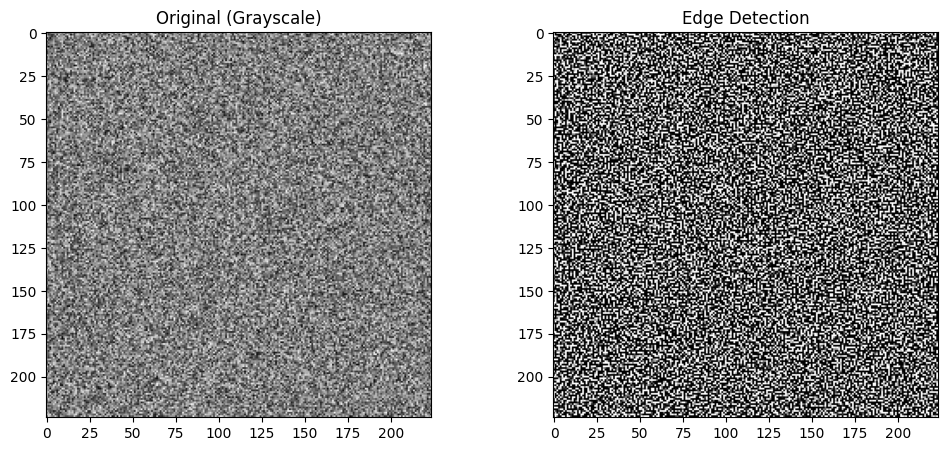

In [20]:
# Edge detection kernel
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

edges = cv2.filter2D(gray, -1, kernel)

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original (Grayscale)')
axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Edge Detection')
plt.show()

### CNN (Convolutional Neural Networks)

CV'de kullanılan temel mimari: **CNN**.

CNN'lerin farkı:
- Her nöron, görüntünün tamamına değil, küçük bir bölgesine bakar

Bu, iki büyük avantaj sağlar:
- Parametre sayısı azalır
- Uzamsal yapı korunur

Model şunu öğrenir:
> "Bu desen, görüntünün neresinde olursa olsun aynıdır."

In [21]:
import torch
import torch.nn as nn

# "3 kanallı bir görüntüden 16 farklı özellik çıkaracağım."
conv = nn.Conv2d(
    in_channels=3,
    out_channels=16,
    kernel_size=3,
    stride=1,
    padding=1
)

print(conv)

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


### Feature Maps: Öğrenilen Temsiller

Convolution sonucu elde edilen çıktılara **feature map** denir.

Her feature map:
- Farklı bir özelliği yakalar (kenar, doku, şekil gibi)

Derinleştikçe:
- Basit desenler birleşir
- Daha karmaşık yapılar oluşur

In [22]:
x = torch.randn(1, 3, 224, 224)  # (batch, C, H, W)
y = conv(x)

print("Feature map shape:", y.shape)  # (1, 16, 224, 224)

Feature map shape: torch.Size([1, 16, 224, 224])


### Pooling: Bilgiyi Sıkıştırmak

Pooling katmanları:
- Uzamsal boyutu küçültür
- Önemli bilgiyi korur

En yaygın olan: **Max Pooling**

Amaç:
- Hesaplama maliyetini düşürmek
- Küçük kaymalara karşı dayanıklılık kazanmak

In [23]:
pool = nn.MaxPool2d(kernel_size=2, stride=2)
y_pool = pool(y)

print("After pooling shape:", y_pool.shape)  # (1, 16, 112, 112)

After pooling shape: torch.Size([1, 16, 112, 112])


### Non-Linearity ve Aktivasyonlar

CNN'lerde de ReLU, Leaky ReLU gibi aktivasyonlar kullanılır.

> Lineerliği kırmadan karmaşıklık öğrenilemez.

In [24]:
relu = nn.ReLU()
y_act = relu(y_pool)
print("After activation shape:", y_act.shape)

After activation shape: torch.Size([1, 16, 112, 112])


### Tam CNN Modeli Örneği

In [25]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Linear(64 * 56 * 56, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = SimpleCNN()
print(model)

# Test forward pass
test_input = torch.randn(1, 3, 224, 224)
output = model(test_input)
print("\nOutput shape:", output.shape)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=200704, out_features=10, bias=True)
)

Output shape: torch.Size([1, 10])


In [26]:
# Tahmin
pred = output.argmax(dim=1)
print("Predicted class:", pred.item())

Predicted class: 4


### Data Augmentation: Görsel Çeşitlilik

CV'de veri pahalıdır. Bu yüzden:
- Döndürme
- Çevirme
- Parlaklık değişimi

gibi işlemlerle veri çeşitlendirilir.

Model şunu öğrenir:
> Nesne değişse bile kimliği değişmez.

In [27]:
from torchvision import transforms

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor()
])

print("Data Augmentation pipeline:")
print(train_tf)

Data Augmentation pipeline:
Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=None, saturation=None, hue=None)
    ToTensor()
)


---
# 4. Speech Technology

Bu kez derin öğrenmenin **zamanla titreşen** haliyle ilgileniyoruz: ses.

Ses teknolojilerinin temel problemi:
> Sürekli, analog, akışkan bir fiziksel olayı ayrık, sayısal ve öğrenilebilir bir temsile dönüştürmek.

### Analogdan Dijitale: Ses Sinyalinin Yolculuğu

1. **Analog Sesin Oluşması**: Ses aslında mekanik bir dalgadır
2. **Elektrik Sinyaline Dönüşüm**: Mikrofon, havadaki basınç değişimlerini elektrik sinyaline çevirir
3. **Analog-Dijital Dönüştürme (ADC)**: Örnekleme (sampling), nicemleme (quantization) ve kodlama (encoding)

**Sampling (Örnekleme)**:
- 16 kHz → saniyede 16.000 örnek
- 44.1 kHz → müzik standardı

**Nyquist prensibi**:
> Yakalamak istediğin en yüksek frekansın en az 2 katı hızda örnekle.

In [28]:
import librosa
import numpy as np

# Demo için sentetik bir ses sinyali oluşturalım
# Gerçek kullanımda: waveform, sample_rate = librosa.load("audio.wav", sr=16000)

sample_rate = 16000
duration = 2.0  # 2 saniyelik ses
t = np.linspace(0, duration, int(sample_rate * duration))

# Birden fazla frekanstan oluşan sentetik ses
waveform = 0.5 * np.sin(2 * np.pi * 440 * t) + 0.3 * np.sin(2 * np.pi * 880 * t)
waveform = waveform.astype(np.float32)

print("Sample rate:", sample_rate)
print("Waveform shape:", waveform.shape)

Sample rate: 16000
Waveform shape: (32000,)


### Waveform (Dalga Formu)

Ses hala waveform halindedir. Zaman domainindedir.
- X ekseni = zaman (ms cinsinden)
- Y ekseni = genlik (amplitüd)

Bu ham veri **çok karmaşıktır**: konuşma için anlamlı özellikleri çıkarmak zordur. O yüzden frekans analizine geçilir.

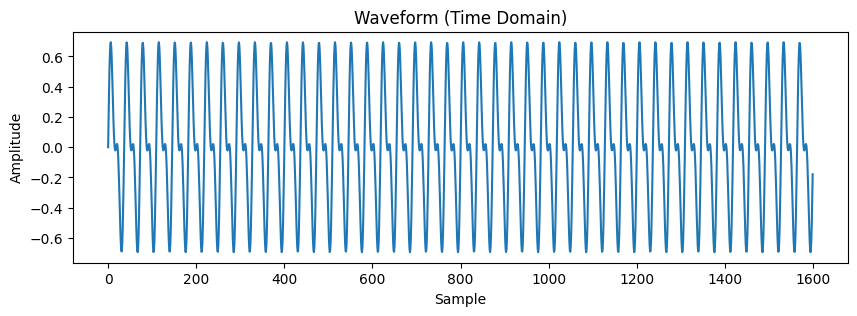

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
plt.plot(waveform[:1600])  # İlk 0.1 saniye
plt.title("Waveform (Time Domain)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

### Spectrogram

Ses teknolojilerindeki kritik fikir:
> Sesi duyarız ama frekansları görerek anlarız.

- X ekseni: zaman
- Y ekseni: frekans
- Renk: enerji

Bu noktada ses: **Computer Vision probleminin kuzeni** olur.

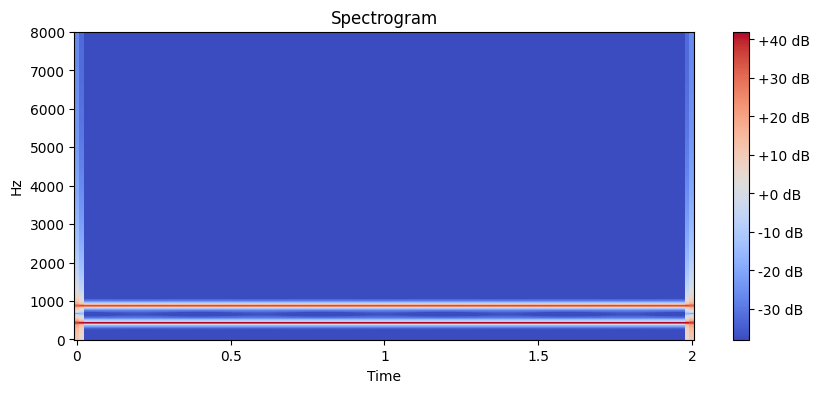

In [30]:
import librosa.display

stft = librosa.stft(waveform, n_fft=1024, hop_length=256)
spectrogram = np.abs(stft)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    librosa.amplitude_to_db(spectrogram),
    sr=sample_rate,
    hop_length=256,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

### Mel-Spectrogram

Klasik spectrogram frekansları lineer eksende gösterir. Ama insan kulağı böyle çalışmaz.

İnsan kulağı:
- Düşük frekanslara çok duyarlı
- Yüksek frekansları daha kaba algılar

**Mel scale**, frekansları insan algısına göre yeniden ölçekleyen bir sistemdir.

Mel-spectrogram:
- Zaman × Mel Bantları × Enerji bilgisi içerir
- Konuşmanın fonetik yapısını korur
- CNN ve Transformer'lar için uygundur

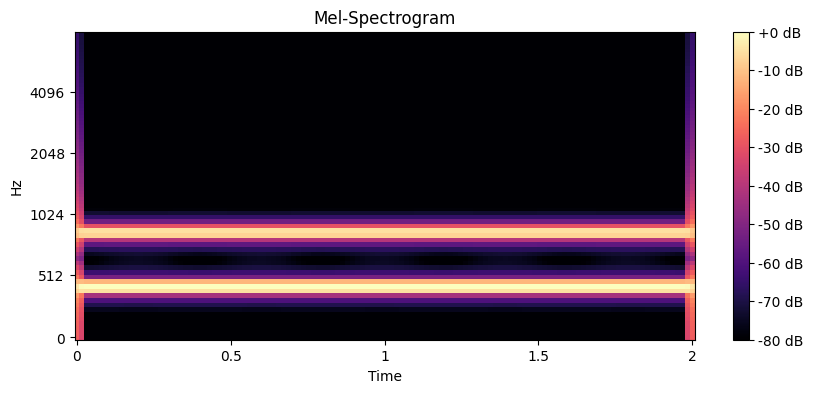

In [31]:
mel_spec = librosa.feature.melspectrogram(
    y=waveform,
    sr=sample_rate,
    n_fft=1024,
    hop_length=256,
    n_mels=80
)

mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mel_spec_db,
    sr=sample_rate,
    hop_length=256,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel-Spectrogram")
plt.show()

In [32]:
import torch

mel_tensor = torch.tensor(mel_spec_db).unsqueeze(0)

print("Mel tensor shape:", mel_tensor.shape)
# (batch_size, n_mels, time)

Mel tensor shape: torch.Size([1, 80, 126])


### MFCC (Mel-Frequency Cepstral Coefficients)

Mel spectrogramın bir adım ilerisidir. Bir özellik çıkarma tekniğidir.
Mel-spectogramdaki önemli bilginin çıkarılıp sıkıştırılmış halidir.

Klasik ASR ve speaker recognition'da yaygındır.

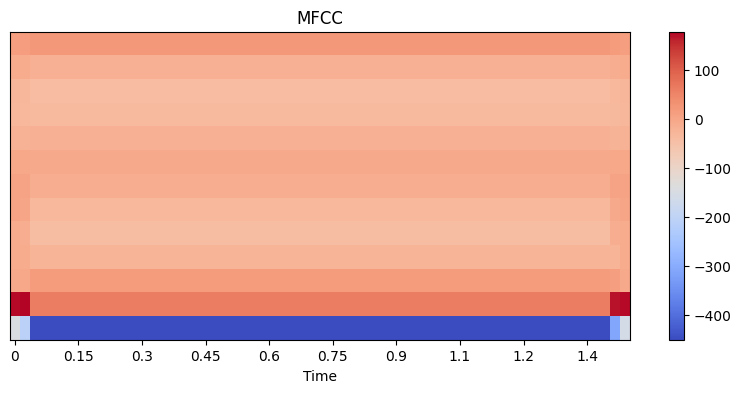

In [33]:
mfcc = librosa.feature.mfcc(
    y=waveform,
    sr=sample_rate,
    n_mfcc=13
)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mfcc,
    x_axis="time"
)
plt.colorbar()
plt.title("MFCC")
plt.show()

### Ses İşleme Pipeline Özeti

**Frequency-domain feature pipeline**:

```
Sinyal → Sampling → FFT → Güç Spektrumu → Spektrogram
Spektrogram → Mel Filtreleri → Mel Spektrogram
Mel Spektrogram → Log → DCT → MFCC
```

Yani zincir:
```
Analog → Dijital → FFT → Spektrogram → Mel → Log-Mel → DCT → MFCC
```

### ASR / STT: Speech-to-Text

**Automatic Speech Recognition (ASR)** ya da **Speech-to-Text (STT)**

Amaç: Ses → metin

Modern ASR girdileri:
- **Mel-spectrogram** (en yaygın) - Wav2Vec 2.0, Whisper, Conformer
- **Log-Mel spectrogram** - DeepSpeech 2
- **Raw waveform** - Wav2Vec 2.0, HuBERT

In [34]:
# Whisper kullanımı için (gerçek ses dosyası gerekir)
# import whisper
#
# model = whisper.load_model("base")
# result = model.transcribe("audio.wav")
# print(result["text"])

print("Whisper kullanımı için bir ses dosyası gereklidir.")
print("Örnek kod:")
print("""
import whisper

model = whisper.load_model("base")
result = model.transcribe("audio.wav")
print(result["text"])
""")

Whisper kullanımı için bir ses dosyası gereklidir.
Örnek kod:

import whisper

model = whisper.load_model("base")
result = model.transcribe("audio.wav")
print(result["text"])



### VAD: Voice Activity Detection

Her ses konuşma değildir.

**VAD**:
- Konuşma var mı?
- Sessizlik mi?

sorusunu yanıtlar. Gerçek zamanlı sistemlerin temel taşıdır.

In [35]:
# WebRTC VAD kullanımı
# import webrtcvad
#
# vad = webrtcvad.Vad(2)  # 0-3 arası hassasiyet
#
# def is_speech(frame, sample_rate=16000):
#     return vad.is_speech(frame, sample_rate)

print("VAD kullanımı için özel formatlı ses verisi gereklidir.")
print("Örnek kod:")
print("""
import webrtcvad

vad = webrtcvad.Vad(2)  # 0-3 arası hassasiyet

def is_speech(frame, sample_rate=16000):
    return vad.is_speech(frame, sample_rate)
""")

VAD kullanımı için özel formatlı ses verisi gereklidir.
Örnek kod:

import webrtcvad

vad = webrtcvad.Vad(2)  # 0-3 arası hassasiyet

def is_speech(frame, sample_rate=16000):
    return vad.is_speech(frame, sample_rate)



### TTS: Text-to-Speech

Modern TTS modelleri:
- Tacotron
- FastSpeech
- VITS
- StyleTTS
- Kokoro TTS

Amaç:
> Doğal, akıcı, insan benzeri konuşma.

In [42]:
print("TTS kullanımı örneği:")
from TTS.api import TTS

tts = TTS(model_name="tts_models/en/ljspeech/tacotron2-DDC")
tts.tts_to_file(
    text="Hello, speech synthesis world!",
    file_path="output.wav"
)


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 862.8/862.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.3/997.3 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 648.4/648.4 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 4.9 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=4ce45f8100ed9b68012cb28a1bb6b17c450fd69a920f583e4922af63bf998ec4
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt
TTS kullanımı örneği:


100%|██████████| 113M/113M [00:01<00:00, 76.6MiB/s]
100%|██████████| 3.80M/3.80M [00:00<00:00, 38.6MiB/s]


'output.wav'

### Grapheme ↔ Phoneme (G2P)

Yazılan harfleri (grapheme) → Telaffuz edilecek seslere (phoneme) çeviren sistem.

- **Grapheme**: yazı birimi (harf)
- **Phoneme**: ses birimi

Örnek:
```
"read" → /riːd/ (present) vs /rɛd/ (past)
"tear" → /tɪr/ (gözyaşı) vs /tɛr/ (yırtmak)
```

In [38]:
# G2P kullanımı
# pip install g2p-en

try:
    import nltk
    nltk.download('averaged_perceptron_tagger_eng')
    from g2p_en import G2p

    g2p = G2p()
    text = "I read a book"
    phonemes = g2p(text)
    print("Text:", text)
    print("Phonemes:", phonemes)
except ImportError:
    print("g2p-en kütüphanesi yüklü değil.")
    print("Yüklemek için: pip install g2p-en")
    print("")
    print("Örnek çıktı:")
    print("Text: I read a book")
    print("Phonemes: ['AY1', ' ', 'R', 'EH1', 'D', ' ', 'AH0', ' ', 'B', 'UH1', 'K']")


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Text: I read a book
Phonemes: ['AY1', ' ', 'R', 'IY1', 'D', ' ', 'AH0', ' ', 'B', 'UH1', 'K']


---
# 5. Multimodal Interaction

İnsanlar tek modaliteyle iletişim kurmaz:
- Ses
- Metin
- Görüntü
- Jest

Modern sistemler:
- Konuşmayı görsel bağlamla
- Metni sesle

birleştirir.

Bu noktada:
> NLP + CV + Speech birleşir.

### Speech Language Models & Vision Language Model

Yeni nesil modeller:
- Konuşmayı anlar, konuşarak yanıtlar
- Metni, sesi ve bağlamı birlikte işler
- Görüntüyü okuyup size anlatabilir
- Pixelleri ve tokenları beraber işler

Bu modeller:
- Transformer tabanlı
- Multimodal
- Büyük ölçekli

Örnek: CLIP, Ultravox, Qwen, Gemini, GPT-5

---
# 6. Büyük Resim

Derin öğrenmede kurduğumuz iskelet hâlâ aynıdır:

> Sinyal → Temsil → Bağlam → Anlam

Ve artık şunu net görüyoruz:

**NLP, CV ve Speech ayrı alanlar değil; aynı zekânın farklı duyuları.**

---
# Kaynaklar

### NLP
- [Stanford CS224N: NLP with Deep Learning](https://www.youtube.com/watch?v=rmVRLeJRkl4&list=PLoROMvodv4rMFqRtEuo6SGjY4XbRIVRd4)
- [Hugging Face LLM Course](https://huggingface.co/learn/llm-course/chapter1/1)
- [DeepLearning.AI NLP Guide](https://www.deeplearning.ai/resources/natural-language-processing/)

### Computer Vision
- [Stanford CS231N: Deep Learning for Computer Vision](https://www.youtube.com/watch?v=2fq9wYslV0A&list=PLoROMvodv4rOmsNzYBMe0gJY2XS8AQg16)
- [Awesome Computer Vision](https://github.com/jbhuang0604/awesome-computer-vision)
- [Awesome Deep Vision](https://github.com/kjw0612/awesome-deep-vision)

### Speech Technology
- [Hugging Face Audio Course](https://huggingface.co/learn/audio-course/chapter0/introduction)
- [Deep Learning for Speech and Language](https://telecombcn-dl.github.io/2017-dlsl/)
- [MIT 6.S191: Automatic Speech Recognition](https://www.youtube.com/watch?v=sR6_bZ6VkAg)

### Önemli Makaleler
- Transformer: https://arxiv.org/abs/1706.03762
- BERT: https://arxiv.org/abs/1810.04805
- GPT-3: https://arxiv.org/abs/2005.14165
- ResNet: https://arxiv.org/abs/1512.03385
- Whisper: https://openai.com/index/whisper/

---
## Kütüphaneler Özeti

### NLP
- **transformers**: Modelleri yükleme, finetune etme, inference
- **tokenizers**: Hızlı düşük seviye tokenization
- **datasets**: Büyük metin datasetleri
- **spaCy, NLTK, Gensim**: NLP özelinde

### Computer Vision
- **NumPy**: Matematiksel işlemler
- **OpenCV (cv2)**: Görüntü işleme
- **Pillow (PIL)**: Grafik işleme
- **torchvision**: PyTorch için CV
- **Ultralytics**: YOLO

### Speech
- **Librosa**: Ses işleme
- **Torchaudio**: Speech modelleri
- **Whisper**: Modern STT
- **ESPnet / NeMo**: Uçtan uca speech

### Genel
- **PyTorch**: Derin öğrenmenin omurgası
- **TensorFlow/Keras**: Alternatif framework
- **Huggingface**: Model ve dataset ekosistemi